# 5G Energy Consumption
### Ml-Based Model Building

# 1. Data Loading and Initial Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

#from google.colab import drive
#drive.mount('/content/gdrive')

In [2]:
# set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [3]:
# Path to the folder containing your CSV files


# base_path = '/content/gdrive/My Drive/upgrad/LJMU/'

# --- Load BSinfo.csv ---
#file_name_bsinfo = 'BSinfo.csv'
#file_path_bsinfo = base_path + file_name_bsinfo
try:
    bs_info = pd.read_csv('BSinfo.csv')
    print(f'CSV file {'BSinfo.csv'} loaded successfully!')
    print(bs_info.head())
except FileNotFoundError:
    print(f"Error: The file '{'BSinfo.csv'}' was not found. Please check the path and filename.")
except Exception as e:
    print(f"An error occurred: {e}")

# --- Load CLdata.csv ---
#file_name_cldata = 'CLdata.csv'
#file_path_cldata = base_path + file_name_cldata
try:
    cl_data = pd.read_csv('CLdata.csv')
    cl_data['Time'] = pd.to_datetime(cl_data['Time'])
    print(f'CSV file {'CLdata.csv'} loaded successfully!')
    print(cl_data.head())
except FileNotFoundError:
    print(f"Error: The file '{'CLdata.csv'}' was not found. Please check the path and filename.")
except Exception as e:
    print(f"An error occurred: {e}")

# --- Load ECdata.csv ---
#file_name_ecdata = 'ECdata.csv'
#file_path_ecdata = base_path + file_name_ecdata
try:
    ec_data = pd.read_csv('ECdata.csv')
    ec_data['Time'] = pd.to_datetime(ec_data['Time'])
    print(f'CSV file {'ECdata.csv'} loaded successfully!')
    print(ec_data.head())
except FileNotFoundError:
    print(f"Error: The file '{'ECdata.csv'}' was not found. Please check the path and filename.")
except Exception as e:
    print(f"An error occurred: {e}")

CSV file BSinfo.csv loaded successfully!
    BS CellName RUType   Mode  Frequency  Bandwidth  Antennas   TXpower
0  B_0    Cell0  Type1  Mode2      365.0         20         4  6.875934
1  B_1    Cell0  Type2  Mode2      532.0         20         4  6.875934
2  B_2    Cell0  Type1  Mode2      365.0         20         4  6.875934
3  B_3    Cell0  Type2  Mode2      532.0         20         4  6.875934
4  B_4    Cell0  Type2  Mode2      532.0         20         4  6.875934
CSV file CLdata.csv loaded successfully!
                 Time   BS CellName      load  ESMode1  ESMode2  ESMode3  \
0 2023-01-01 01:00:00  B_0    Cell0  0.487936      0.0      0.0      0.0   
1 2023-01-01 02:00:00  B_0    Cell0  0.344468      0.0      0.0      0.0   
2 2023-01-01 03:00:00  B_0    Cell0  0.193766      0.0      0.0      0.0   
3 2023-01-01 04:00:00  B_0    Cell0  0.222383      0.0      0.0      0.0   
4 2023-01-01 05:00:00  B_0    Cell0  0.175436      0.0      0.0      0.0   

   ESMode4  ESMode5  ESMode6 

In [4]:
# Display basic information
print("Base station information (BSinfo.csv)")
print(f"shape: {bs_info.shape}")
print(f"columns: {list(bs_info.columns)}")
print ("\n first few rows: \n")
print (bs_info.head())
print("\n data types")
print(bs_info.dtypes)


Base station information (BSinfo.csv)
shape: (1217, 8)
columns: ['BS', 'CellName', 'RUType', 'Mode', 'Frequency', 'Bandwidth', 'Antennas', 'TXpower']

 first few rows: 

    BS CellName RUType   Mode  Frequency  Bandwidth  Antennas   TXpower
0  B_0    Cell0  Type1  Mode2      365.0         20         4  6.875934
1  B_1    Cell0  Type2  Mode2      532.0         20         4  6.875934
2  B_2    Cell0  Type1  Mode2      365.0         20         4  6.875934
3  B_3    Cell0  Type2  Mode2      532.0         20         4  6.875934
4  B_4    Cell0  Type2  Mode2      532.0         20         4  6.875934

 data types
BS            object
CellName      object
RUType        object
Mode          object
Frequency    float64
Bandwidth      int64
Antennas       int64
TXpower      float64
dtype: object


In [5]:
# Display basic information for df_CLdata
print("Cell data information (CLdata.csv)")
print(f"shape: {cl_data.shape}")
print(f"columns: {list(cl_data.columns)}")
print ("\n first few rows: \n")
print (cl_data.head())
print("\n data types")
print(cl_data.dtypes)



Cell data information (CLdata.csv)
shape: (125575, 10)
columns: ['Time', 'BS', 'CellName', 'load', 'ESMode1', 'ESMode2', 'ESMode3', 'ESMode4', 'ESMode5', 'ESMode6']

 first few rows: 

                 Time   BS CellName      load  ESMode1  ESMode2  ESMode3  \
0 2023-01-01 01:00:00  B_0    Cell0  0.487936      0.0      0.0      0.0   
1 2023-01-01 02:00:00  B_0    Cell0  0.344468      0.0      0.0      0.0   
2 2023-01-01 03:00:00  B_0    Cell0  0.193766      0.0      0.0      0.0   
3 2023-01-01 04:00:00  B_0    Cell0  0.222383      0.0      0.0      0.0   
4 2023-01-01 05:00:00  B_0    Cell0  0.175436      0.0      0.0      0.0   

   ESMode4  ESMode5  ESMode6  
0        0      0.0      0.0  
1        0      0.0      0.0  
2        0      0.0      0.0  
3        0      0.0      0.0  
4        0      0.0      0.0  

 data types
Time        datetime64[ns]
BS                  object
CellName            object
load               float64
ESMode1            float64
ESMode2            float

In [6]:
# Display basic information for df_ECdata
print("\nEC data information (ECdata.csv)")
print(f"shape: {ec_data.shape}")
print(f"columns: {list(ec_data.columns)}")
print ("\n first few rows: \n")
print (ec_data.head())
print("\n data types")
print(ec_data.dtypes)


EC data information (ECdata.csv)
shape: (92629, 3)
columns: ['Time', 'BS', 'Energy']

 first few rows: 

                 Time   BS     Energy
0 2023-01-01 01:00:00  B_0  64.275037
1 2023-01-01 02:00:00  B_0  55.904335
2 2023-01-01 03:00:00  B_0  57.698057
3 2023-01-01 04:00:00  B_0  55.156951
4 2023-01-01 05:00:00  B_0  56.053812

 data types
Time      datetime64[ns]
BS                object
Energy           float64
dtype: object


In [7]:
# check for missing values
print("\nMissing values in BSinfo.csv:")
print(bs_info.isnull().sum())

print("\nMissing values in CLdata.csv:")
print(cl_data.isnull().sum())

print("\nMissing values in ECdata.csv:")
print(ec_data.isnull().sum())


Missing values in BSinfo.csv:
BS           0
CellName     0
RUType       0
Mode         0
Frequency    0
Bandwidth    0
Antennas     0
TXpower      0
dtype: int64

Missing values in CLdata.csv:
Time        0
BS          0
CellName    0
load        0
ESMode1     0
ESMode2     0
ESMode3     0
ESMode4     0
ESMode5     0
ESMode6     0
dtype: int64

Missing values in ECdata.csv:
Time      0
BS        0
Energy    0
dtype: int64


# 2. Exploratory data Analysis(EDA)

In [8]:
# statistical summary of numerical columns
print("\nStatistical summary of numerical columns in bsinfo.csv:")
print(bs_info.describe())
print("\nStatistical summary of numerical columns in CLdata.csv:")
print(cl_data.describe())
print("\nStatistical summary of numerical columns in ECData.csv:")
print(ec_data.describe())


Statistical summary of numerical columns in bsinfo.csv:
         Frequency    Bandwidth     Antennas      TXpower
count  1217.000000  1217.000000  1217.000000  1217.000000
mean    408.413334    12.706656     3.908792     6.924197
std     158.536230     7.397005     9.115707     0.464575
min     155.600000     2.000000     1.000000     5.381166
25%     365.000000     8.000000     2.000000     6.576981
50%     426.980000    10.000000     2.000000     6.875934
75%     532.000000    20.000000     2.000000     7.325859
max     979.998000    20.000000    64.000000     8.375336

Statistical summary of numerical columns in CLdata.csv:
                                Time           load        ESMode1  \
count                         125575  125575.000000  125575.000000   
mean   2023-01-03 22:42:31.291260160       0.239009       0.040127   
min              2023-01-01 01:00:00       0.000000       0.000000   
25%              2023-01-02 09:00:00       0.055080       0.000000   
50%           

In [9]:
# value counts for categorical columns
print("RUType distribution:")
print(bs_info['RUType'].value_counts())

print("\nMode distribution:")
print(bs_info['Mode'].value_counts())

print("\nUnique Base Stations:")
print(bs_info['BS'].nunique())
print(f"Base stations:{sorted(bs_info['BS'].unique())}")


RUType distribution:
RUType
Type1     401
Type4     231
Type6     199
Type7     116
Type5      67
Type3      49
Type11     36
Type2      35
Type9      27
Type12     22
Type10     21
Type8      13
Name: count, dtype: int64

Mode distribution:
Mode
Mode2    1125
Mode1      92
Name: count, dtype: int64

Unique Base Stations:
1020
Base stations:['B_0', 'B_1', 'B_10', 'B_100', 'B_1000', 'B_1001', 'B_1002', 'B_1003', 'B_1004', 'B_1005', 'B_1006', 'B_1007', 'B_1008', 'B_1009', 'B_101', 'B_1010', 'B_1011', 'B_1012', 'B_1013', 'B_1014', 'B_1015', 'B_1016', 'B_1017', 'B_1018', 'B_1019', 'B_102', 'B_103', 'B_104', 'B_105', 'B_106', 'B_107', 'B_108', 'B_109', 'B_11', 'B_110', 'B_111', 'B_112', 'B_113', 'B_114', 'B_115', 'B_116', 'B_117', 'B_118', 'B_119', 'B_12', 'B_120', 'B_121', 'B_122', 'B_123', 'B_124', 'B_125', 'B_126', 'B_127', 'B_128', 'B_129', 'B_13', 'B_130', 'B_131', 'B_132', 'B_133', 'B_134', 'B_135', 'B_136', 'B_137', 'B_138', 'B_139', 'B_14', 'B_140', 'B_141', 'B_142', 'B_143', 'B_144

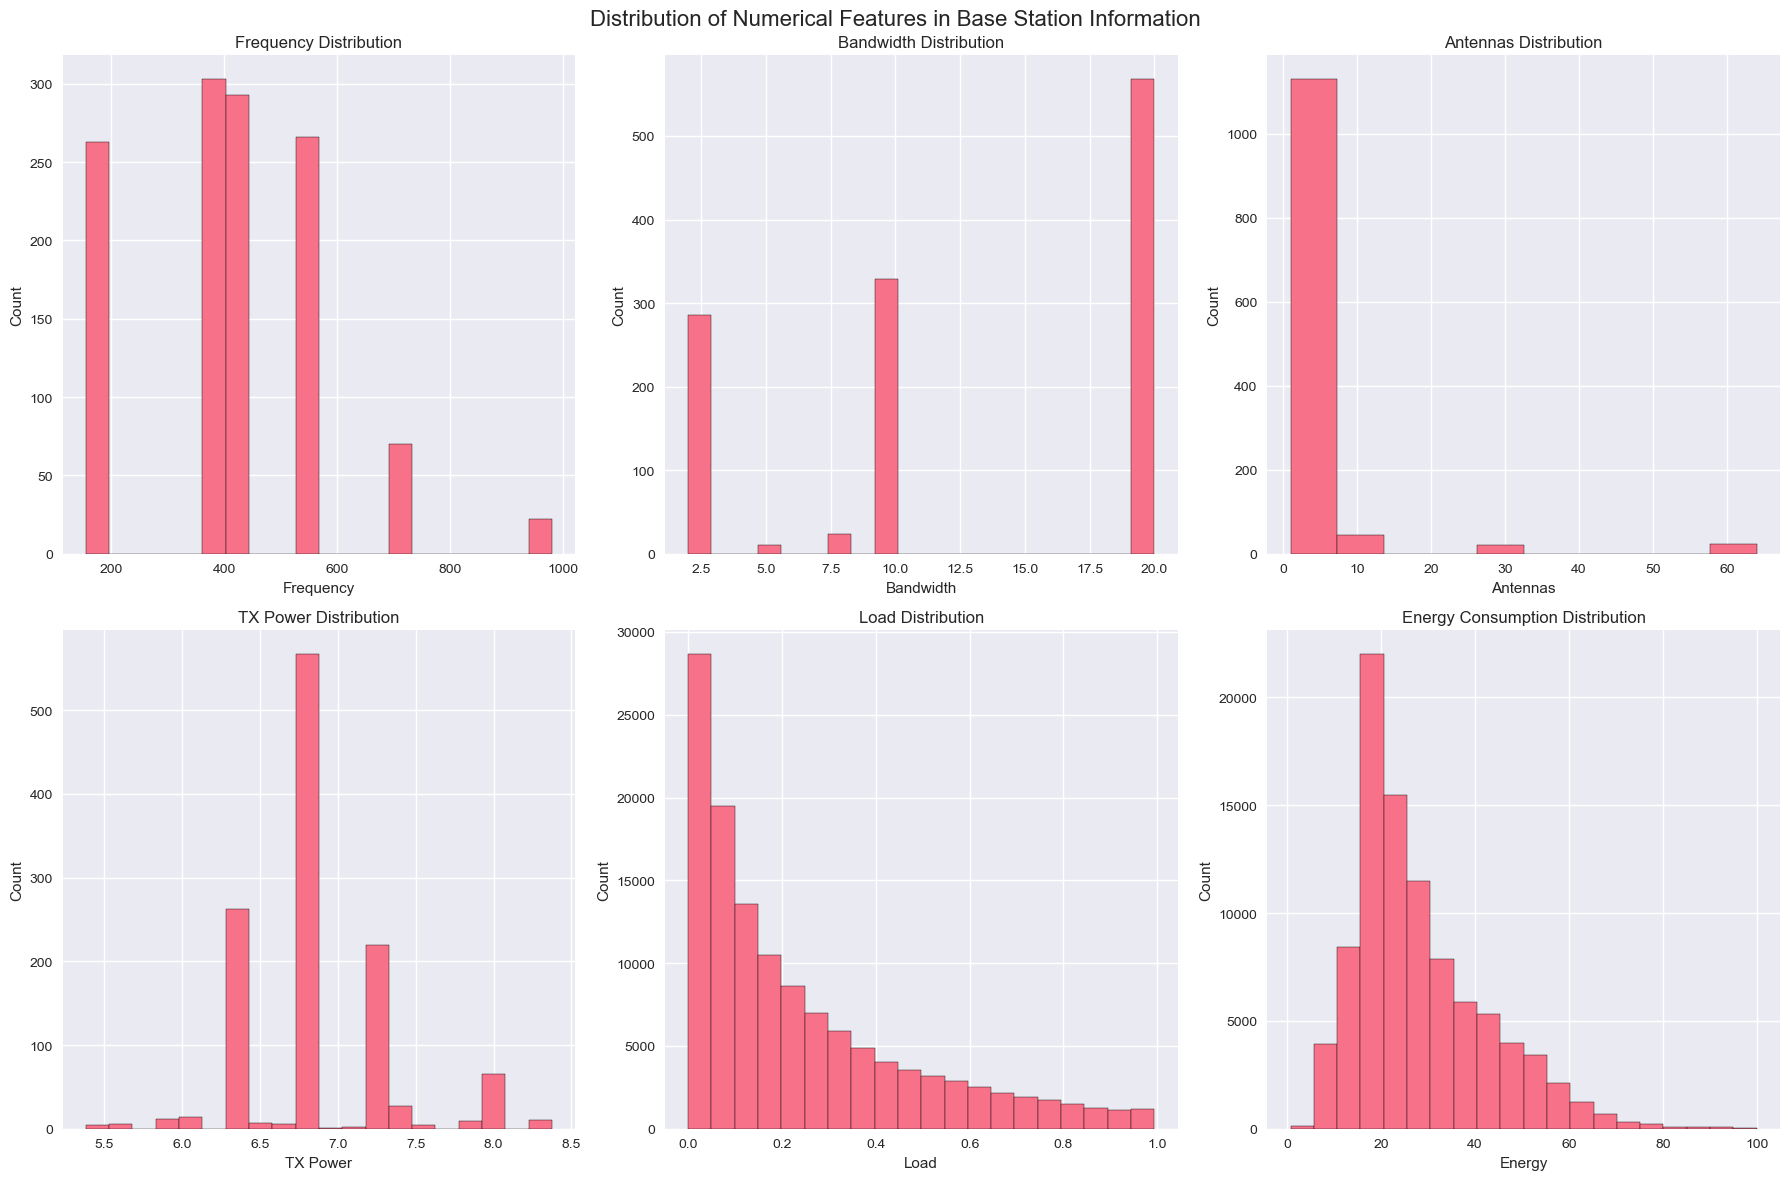

In [10]:
# Distribution plots for numerical features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Distribution of Numerical Features in Base Station Information', fontsize=16)

# Frequency distribution
axes[0, 0].hist(bs_info['Frequency'], bins=20, edgecolor='black')
axes[0, 0].set_title('Frequency Distribution')
axes[0, 0].set_xlabel('Frequency')
axes[0, 0].set_ylabel('Count')

# Bandwidth distribution
axes[0, 1].hist(bs_info['Bandwidth'], bins=20, edgecolor='black')
axes[0, 1].set_title('Bandwidth Distribution')
axes[0, 1].set_xlabel('Bandwidth')
axes[0, 1].set_ylabel('Count')

# Antennas distribution
axes[0, 2].hist(bs_info['Antennas'], bins=10, edgecolor='black')
axes[0, 2].set_title('Antennas Distribution')
axes[0, 2].set_xlabel('Antennas')
axes[0, 2].set_ylabel('Count')

# TX Power distribution
axes[1, 0].hist(bs_info['TXpower'], bins=20, edgecolor='black')
axes[1, 0].set_title('TX Power Distribution')
axes[1, 0].set_xlabel('TX Power')
axes[1, 0].set_ylabel('Count')

# Load distribution
axes[1, 1].hist(cl_data['load'], bins=20, edgecolor='black')
axes[1, 1].set_title('Load Distribution')
axes[1, 1].set_xlabel('Load')
axes[1, 1].set_ylabel('Count')

# Energy distribution
axes[1, 2].hist(ec_data['Energy'], bins=20, edgecolor='black')
axes[1, 2].set_title('Energy Consumption Distribution')
axes[1, 2].set_xlabel('Energy')
axes[1, 2].set_ylabel('Count')

plt.tight_layout()
plt.show()

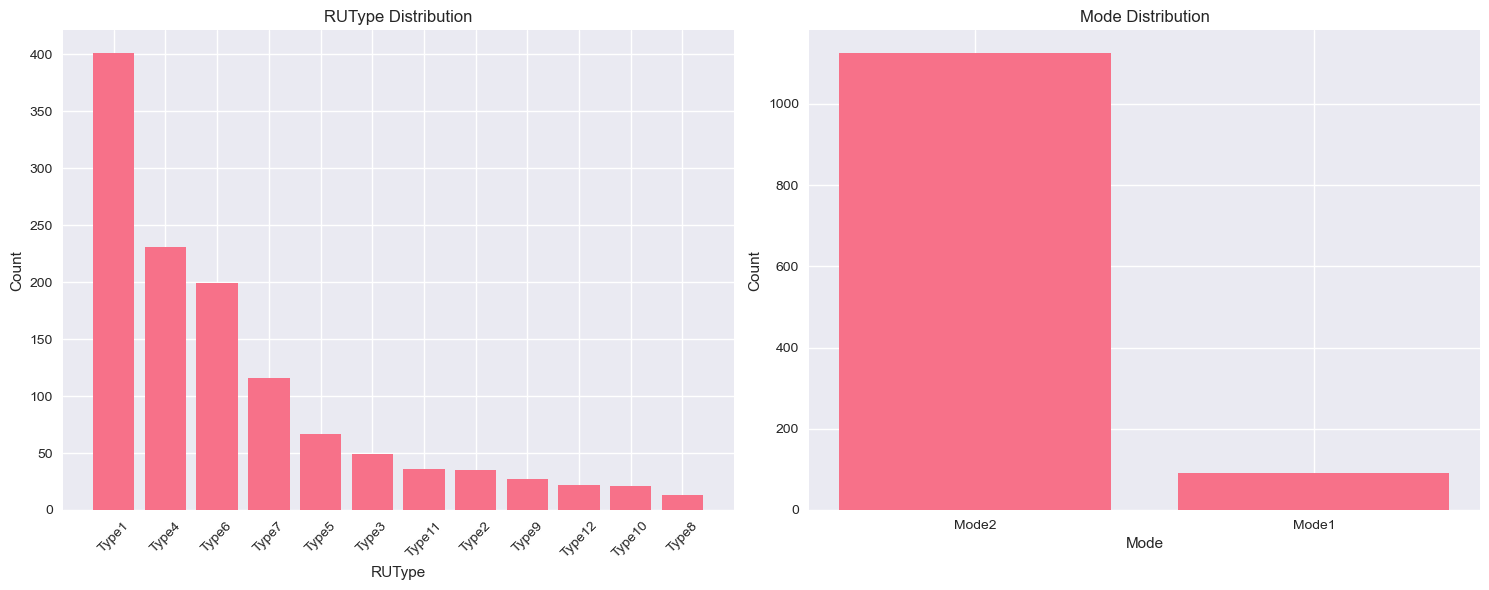

In [11]:
# Categorical feature analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# RUType distribution
ru_counts = bs_info['RUType'].value_counts()
axes[0].bar(range(len(ru_counts)), ru_counts.values)
axes[0].set_title('RUType Distribution')
axes[0].set_xlabel('RUType')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(len(ru_counts)))
axes[0].set_xticklabels(ru_counts.index, rotation=45)

# Mode distribution
mode_counts = bs_info['Mode'].value_counts()
axes[1].bar(range(len(mode_counts)), mode_counts.values)
axes[1].set_title('Mode Distribution')
axes[1].set_xlabel('Mode')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(len(mode_counts)))
axes[1].set_xticklabels(mode_counts.index)

plt.tight_layout()

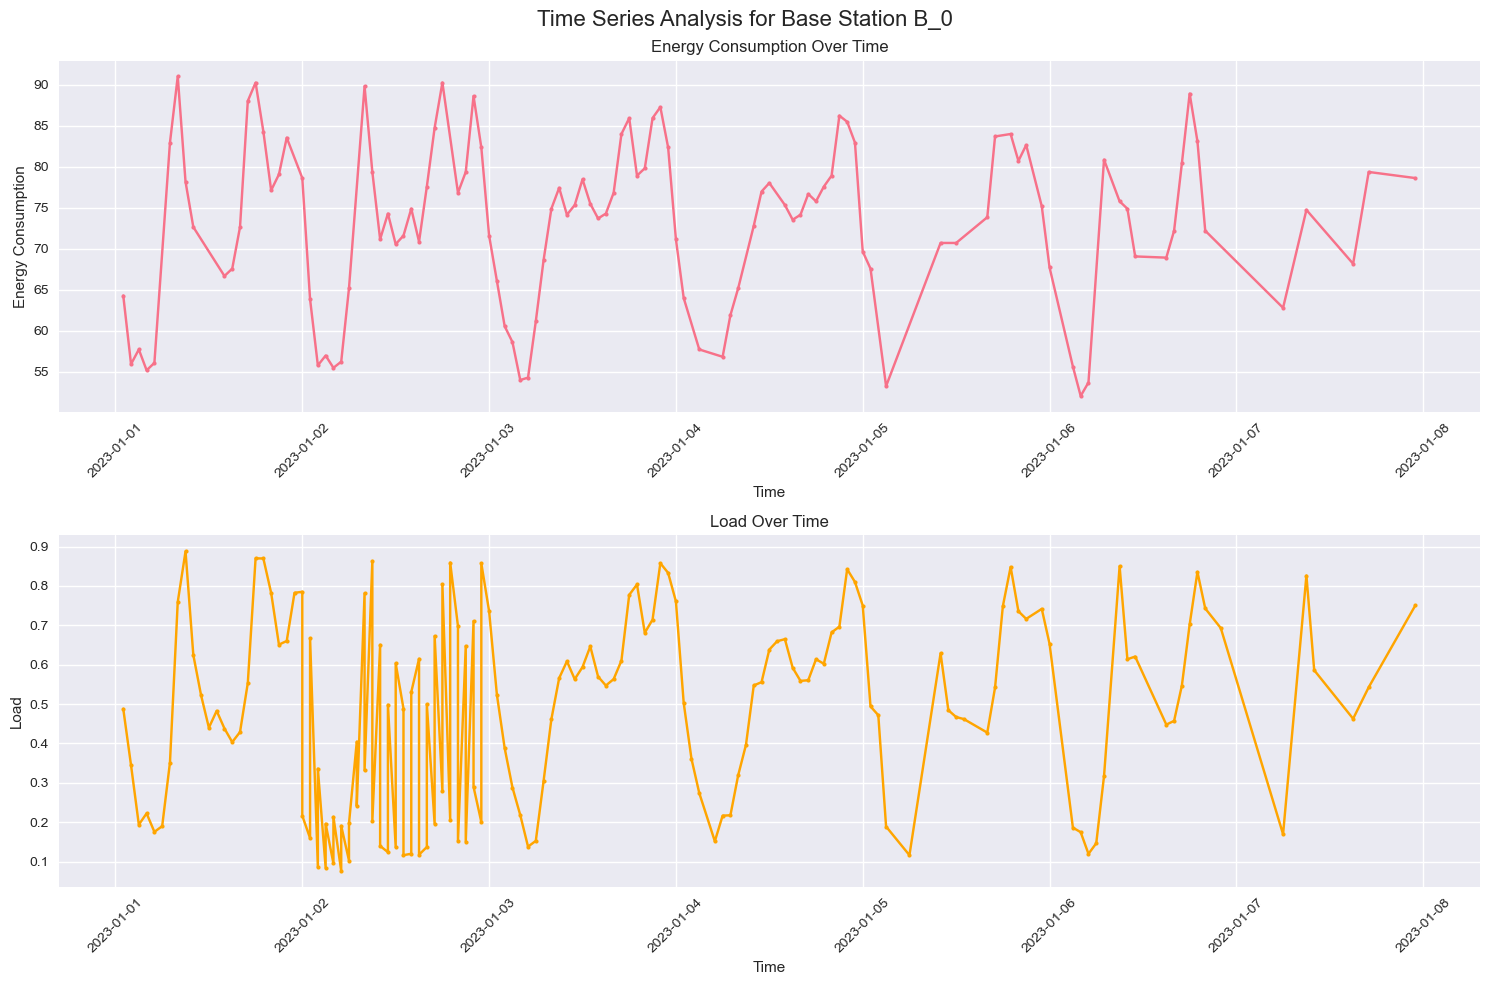

In [12]:
# Time series analysis
# Sample one base station for time series visualization
sample_bs = ec_data['BS'].iloc[0]
ec_sample = ec_data[ec_data['BS'] == sample_bs].sort_values('Time')
cl_sample = cl_data[cl_data['BS'] == sample_bs].sort_values('Time')

fig, axes = plt.subplots(2, 1, figsize=(15, 10))
fig.suptitle(f'Time Series Analysis for Base Station {sample_bs}', fontsize=16)
# Energy consumption over time
axes[0].plot(ec_sample['Time'], ec_sample['Energy'], marker='o', linestyle='-', markersize=3)
axes[0].set_title('Energy Consumption Over Time')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Energy Consumption')
axes[0].tick_params(axis='x', rotation=45)
#Load over time
axes[1].plot(cl_sample['Time'], cl_sample['load'], marker='o', linestyle='-', markersize=3, color='orange')
axes[1].set_title('Load Over Time')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Load')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


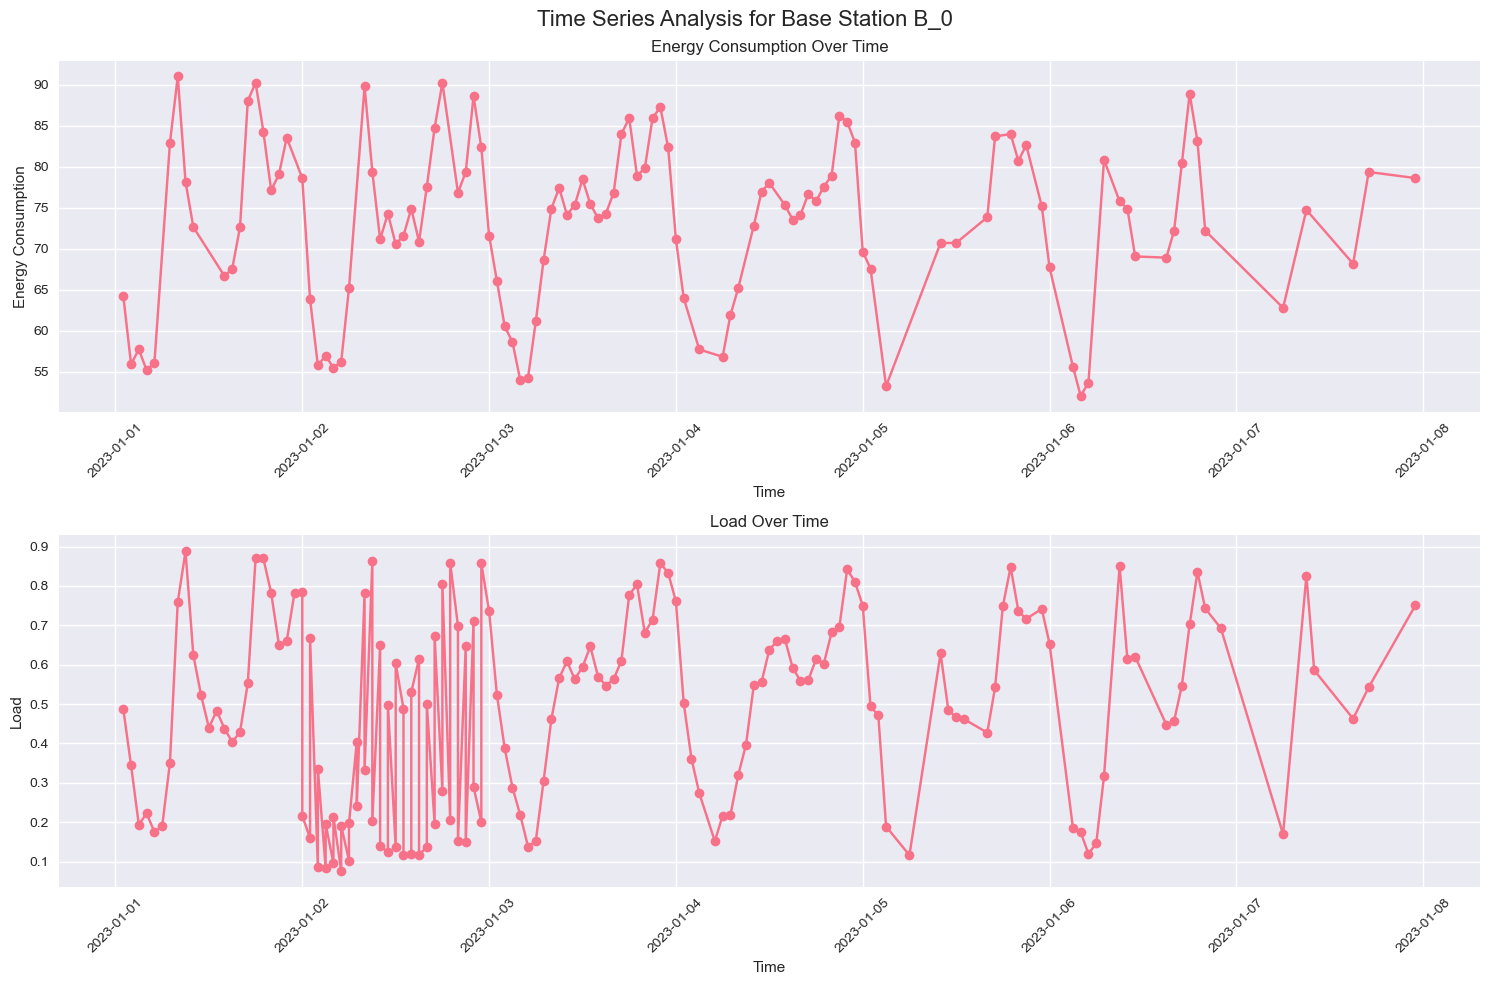

In [13]:
# Time series analysis
# Sample one base station for time series visualization
sample_bs = ec_data['BS'].iloc[0]
ec_sample = ec_data[ec_data['BS'] == sample_bs].sort_values('Time')
cl_sample = cl_data[cl_data['BS'] == sample_bs].sort_values('Time')

fig, axes = plt.subplots(2, 1, figsize=(15, 10))
fig.suptitle(f'Time Series Analysis for Base Station {sample_bs}', fontsize=16)

# Energy consumption over time
axes[0].plot(ec_sample['Time'], ec_sample['Energy'], marker='o', linestyle='-')
axes[0].set_title('Energy Consumption Over Time')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Energy Consumption')
axes[0].tick_params(axis='x', rotation=45)

# Load over time
axes[1].plot(cl_sample['Time'], cl_sample['load'], marker='o', linestyle='-')
axes[1].set_title('Load Over Time')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Load')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


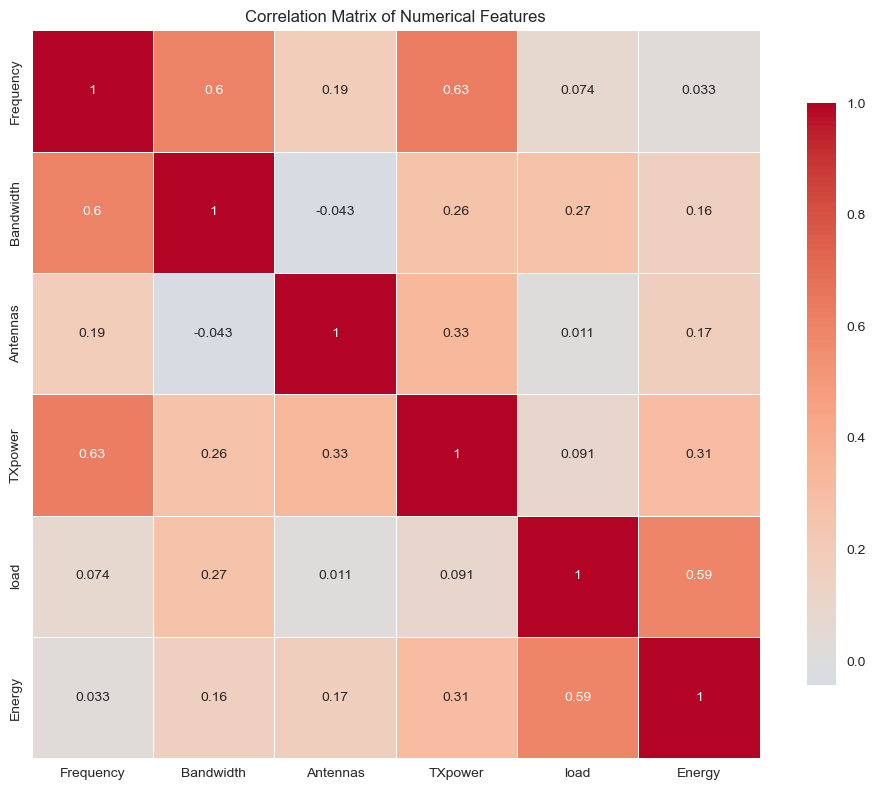

Correlation with Energy Consumption:
Energy       1.000000
load         0.594971
TXpower      0.309092
Antennas     0.165551
Bandwidth    0.160808
Frequency    0.033196
Name: Energy, dtype: float64


In [14]:
# Correlation analysis
# Merge datasets for correlation analysis
merged_data = pd.merge(bs_info, cl_data, on=['BS', 'CellName'])
merged_data = pd.merge(merged_data, ec_data, on=['BS', 'Time'])

# Select numerical columns for correlation
numerical_cols = ['Frequency', 'Bandwidth', 'Antennas', 'TXpower', 'load', 'Energy']
correlation_data = merged_data[numerical_cols]

# Compute correlation matrix
corr_matrix = correlation_data.corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': .8})
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

print("Correlation with Energy Consumption:")
print(corr_matrix['Energy'].sort_values(ascending=False))


Text(0, 0.5, 'Energy Consumption')

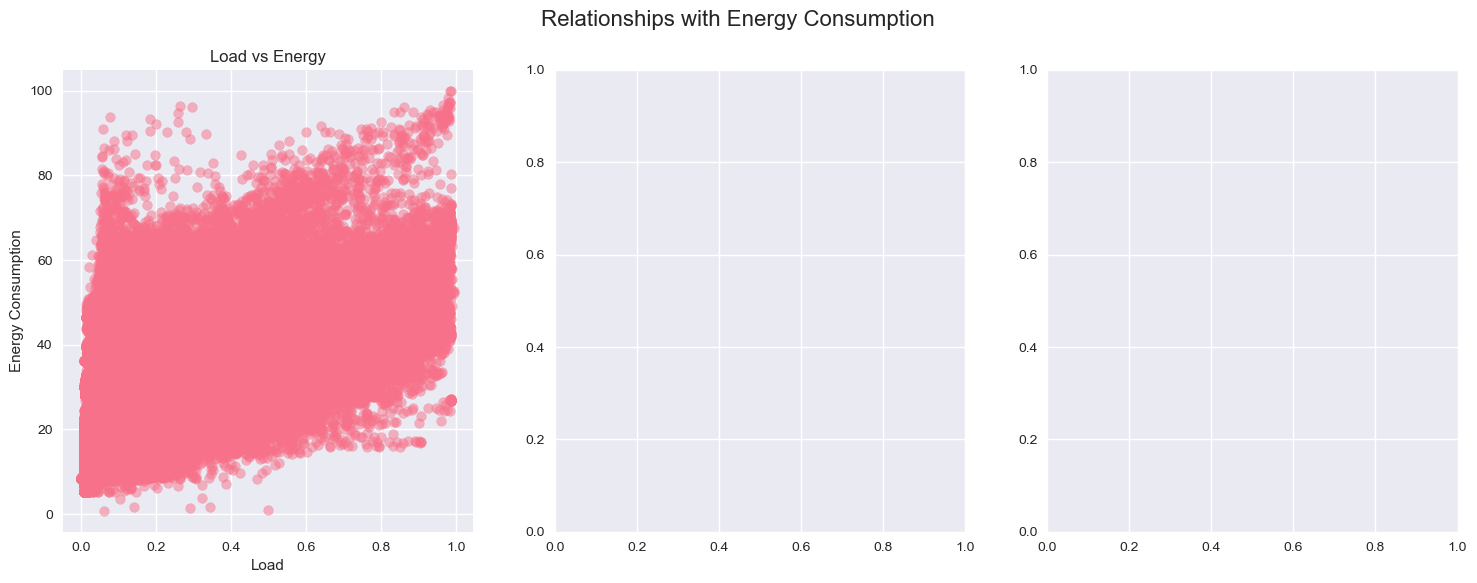

In [15]:
# Scatter plots for key relationships
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Relationships with Energy Consumption', fontsize=16)

# Load vs Energy
axes[0].scatter(merged_data['load'], merged_data['Energy'], alpha=0.5)
axes[0].set_title('Load vs Energy')
axes[0].set_xlabel('Load')
axes[0].set_ylabel('Energy Consumption')


In [16]:
# TX Power vs Energy
axes[0].set_title('Load vs Energy Consumption')
axes[0].set_xlabel('Load')
axes[0].set_ylabel('Energy Consumption')

# TX Power vs Energy
axes[1].scatter(merged_data['TXpower'], merged_data['Energy'], alpha=0.5)
axes[1].set_title('TX Power vs Energy Consumption')
axes[1].set_xlabel('TX Power')
axes[1].set_ylabel('Energy Consumption')

# Frequency vs Energy
axes[2].scatter(merged_data['Frequency'], merged_data['Energy'], alpha=0.5)
axes[2].set_title('Frequency vs Energy Consumption')
axes[2].set_xlabel('Frequency')
axes[2].set_ylabel('Energy Consumption')

plt.tight_layout()
plt.show()


<Figure size 800x550 with 0 Axes>

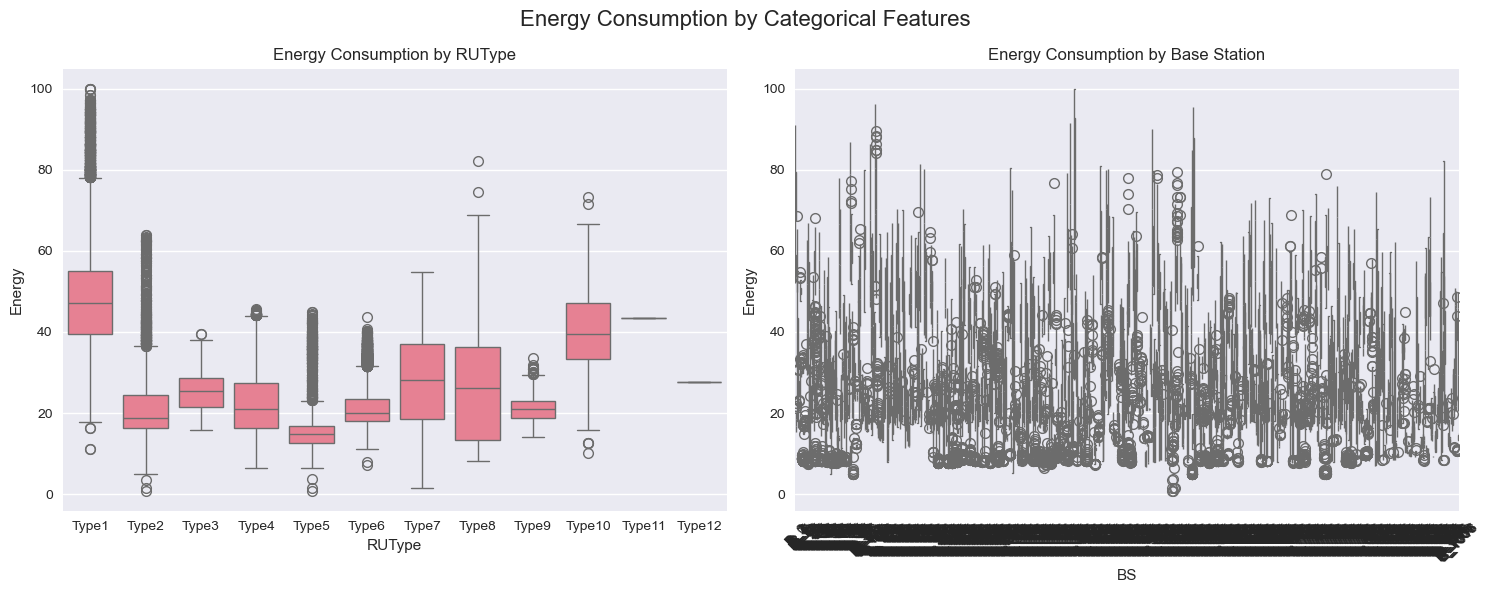

In [17]:
# Box plots for categorical comparisons
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Energy Consumption by Categorical Features', fontsize=16)

# Merge data for categorical analysis
cat_data = pd.merge(bs_info[['BS', 'RUType']], ec_data, on='BS')

# Energy consumption by RUType
sns.boxplot(data=cat_data, x='RUType', y='Energy', ax=axes[0])
axes[0].set_title('Energy Consumption by RUType')

# Energy consumption by different base stations
sns.boxplot(data=ec_data, x='BS', y='Energy', ax=axes[1])
axes[1].set_title('Energy Consumption by Base Station')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [18]:
# 3. Data Preprocessing

# Data cleaning - check for duplicates
print("Duplicate rows in BS Info:", bs_info.duplicated().sum())
print("Duplicate rows in Cell Load Data:", cl_data.duplicated().sum())
print("Duplicate rows in Energy Consumption Data:", ec_data.duplicated().sum())

# Check for inconsistent data
print("\nUnique values in Mode column:", bs_info['Mode'].unique())
print("Unique values in CellName column:", bs_info['CellName'].unique())

# Check for outliers in numerical columns
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers


Duplicate rows in BS Info: 0
Duplicate rows in Cell Load Data: 0
Duplicate rows in Energy Consumption Data: 0

Unique values in Mode column: ['Mode2' 'Mode1']
Unique values in CellName column: ['Cell0' 'Cell1' 'Cell2' 'Cell3']


In [19]:
print("\nOutliers in Energy consumption:")
energy_outliers = detect_outliers(ec_data, 'Energy')
print(f"Number of outliers: {len(energy_outliers)}")

print("\nOutliers in Load:")
load_outliers = detect_outliers(cl_data, 'load')
print(f"Number of outliers: {len(load_outliers)}")


Outliers in Energy consumption:
Number of outliers: 2192

Outliers in Load:
Number of outliers: 4958


In [20]:
# Data integration - create a unified dataset
# First, let’s examine the time range and frequency of data
print("Time range in Cell Load Data:")
print(f"Start: {cl_data['Time'].min()}, End: {cl_data['Time'].max()}")
print(f"Unique timestamps: {cl_data['Time'].nunique()}")

print("\nTime range in Energy Consumption Data:")
print(f"Start: {ec_data['Time'].min()}, End: {ec_data['Time'].max()}")
print(f"Unique timestamps: {ec_data['Time'].nunique()}")

# Check data consistency
print("\nBase stations in BS Info:", sorted(bs_info['BS'].unique()))
print("Base stations in Cell Load Data:", sorted(cl_data['BS'].unique()))
print("Base stations in Energy Consumption Data:", sorted(ec_data['BS'].unique()))


Time range in Cell Load Data:
Start: 2023-01-01 01:00:00, End: 2023-01-08 00:00:00
Unique timestamps: 168

Time range in Energy Consumption Data:
Start: 2023-01-01 01:00:00, End: 2023-01-08 00:00:00
Unique timestamps: 168

Base stations in BS Info: ['B_0', 'B_1', 'B_10', 'B_100', 'B_1000', 'B_1001', 'B_1002', 'B_1003', 'B_1004', 'B_1005', 'B_1006', 'B_1007', 'B_1008', 'B_1009', 'B_101', 'B_1010', 'B_1011', 'B_1012', 'B_1013', 'B_1014', 'B_1015', 'B_1016', 'B_1017', 'B_1018', 'B_1019', 'B_102', 'B_103', 'B_104', 'B_105', 'B_106', 'B_107', 'B_108', 'B_109', 'B_11', 'B_110', 'B_111', 'B_112', 'B_113', 'B_114', 'B_115', 'B_116', 'B_117', 'B_118', 'B_119', 'B_12', 'B_120', 'B_121', 'B_122', 'B_123', 'B_124', 'B_125', 'B_126', 'B_127', 'B_128', 'B_129', 'B_13', 'B_130', 'B_131', 'B_132', 'B_133', 'B_134', 'B_135', 'B_136', 'B_137', 'B_138', 'B_139', 'B_14', 'B_140', 'B_141', 'B_142', 'B_143', 'B_144', 'B_145', 'B_146', 'B_147', 'B_148', 'B_149', 'B_15', 'B_150', 'B_151', 'B_152', 'B_153', 'B

In [21]:
# Handle missing time data in CLdata_mod.csv
def create_complete_time_series(data, freq='H'):
    # Get all unique base stations
    base_stations = data['BS'].unique()

    # Get complete time range
    min_time = data['Time'].min()
    max_time = data['Time'].max()

    # Create complete time range
    complete_time_range = pd.date_range(start=min_time, end=max_time, freq=freq)

    # Create complete dataset
    complete_data_list = []

    for bs in base_stations:
        # Create dataframe with complete time range for this base station
        bs_complete = pd.DataFrame({
            'Time': complete_time_range,
            'BS': bs
        })

        # Merge with actual data
        bs_data = data[data['BS'] == bs]
        bs_complete = pd.merge(bs_complete, bs_data, on=['Time', 'BS'], how='left')

        complete_data_list.append(bs_complete)

    # Combine all base stations
    complete_data = pd.concat(complete_data_list, ignore_index=True)
    return complete_data


In [22]:
# Apply to cell load data
print("Creating complete time series for cell load data...")
cl_data_complete = create_complete_time_series(cl_data)
print(f"Original CL data shape: {cl_data.shape}")
print(f"Complete CL data shape: {cl_data_complete.shape}")
print(f"Percentage of missing load data: {cl_data_complete['load'].isnull().sum()}")

# Handle missing values
# For load data, we'll use forward fill and backward fill
cl_data_complete = cl_data_complete.sort_values(['BS', 'Time'])
cl_data_complete['load'] = cl_data_complete.groupby('BS')['load'].fillna(method='ffill').fillna(method='bfill')

# For ESMode columns, fill with 0 (assuming 0 means not active)
es_mode_cols = ['ESMode1', 'ESMode2', 'ESMode3', 'ESMode4', 'ESMode5', 'ESMode6']
for col in es_mode_cols:
    cl_data_complete[col] = cl_data_complete[col].fillna(0)

# For energy data, we'll also create complete time series
ec_data_complete = create_complete_time_series(ec_data)
ec_data_complete = ec_data_complete.sort_values(['BS', 'Time'])
ec_data_complete['Energy'] = ec_data_complete.groupby('BS')['Energy'].fillna(method='ffill').fillna(method='bfill')

print(f"\nCL data missing load: {cl_data_complete['load'].isnull().sum()}")
print(f"EC data missing Energy: {ec_data_complete['Energy'].isnull().sum()}")


Creating complete time series for cell load data...
Original CL data shape: (125575, 10)
Complete CL data shape: (178167, 10)
Percentage of missing load data: 52592

CL data missing load: 0
EC data missing Energy: 0


In [23]:
# Merge all datasets
# First merge base station info with cell load data
merged_data = pd.merge(cl_data_complete, bs_info, on=['BS', 'CellName'], how='left')

# Then merge with energy consumption data
merged_data = pd.merge(merged_data, ec_data_complete[['Time', 'BS', 'Energy']], on=['BS', 'Time'])

print(f"Merged dataset shape: {merged_data.shape}")
print("\nMissing values in merged dataset:")
print(merged_data.isnull().sum())

# Handle any remaining missing values
merged_data['Energy'] = merged_data.groupby('BS')['Energy'].fillna(method='ffill')
merged_data['CellName'] = merged_data['CellName'].fillna('Cell0')  # All seem to belong to same pattern

print("\nAfter final missing value handling:")
print(merged_data.isnull().sum())


Merged dataset shape: (161823, 17)

Missing values in merged dataset:
Time             0
BS               0
CellName     39200
load             0
ESMode1          0
ESMode2          0
ESMode3          0
ESMode4          0
ESMode5          0
ESMode6          0
RUType       39200
Mode         39200
Frequency    39200
Bandwidth    39200
Antennas     39200
TXpower      39200
Energy           0
dtype: int64

After final missing value handling:
Time             0
BS               0
CellName         0
load             0
ESMode1          0
ESMode2          0
ESMode3          0
ESMode4          0
ESMode5          0
ESMode6          0
RUType       39200
Mode         39200
Frequency    39200
Bandwidth    39200
Antennas     39200
TXpower      39200
Energy           0
dtype: int64


In [24]:
# Feature scaling
from sklearn.preprocessing import StandardScaler


In [25]:
# Select numerical features for scaling
numerical_features = ['Frequency', 'Bandwidth', 'Antennas', 'TXpower', 'load']

# Initialize scaler
scaler = StandardScaler()

# Apply scaling
merged_data_scaled = merged_data.copy()
merged_data_scaled[numerical_features] = scaler.fit_transform(merged_data[numerical_features])

print("Feature scaling completed.")
print("\nOriginal data statistics:")
print(merged_data[numerical_features].describe())
print("\nScaled data statistics:")
print(merged_data_scaled[numerical_features].describe())


Feature scaling completed.

Original data statistics:
           Frequency      Bandwidth       Antennas        TXpower  \
count  122623.000000  122623.000000  122623.000000  122623.000000   
mean      369.078999      15.976089       2.199604       6.733251   
std       136.617494       5.632334       2.203249       0.306187   
min       155.600000       2.000000       1.000000       5.381166   
25%       189.000000      10.000000       2.000000       6.427504   
50%       365.000000      20.000000       2.000000       6.875934   
75%       532.000000      20.000000       2.000000       6.875934   
max       979.998000      20.000000      64.000000       8.375336   

                load  
count  161823.000000  
mean        0.234133  
std         0.230391  
min         0.000000  
25%         0.054400  
50%         0.152100  
75%         0.341912  
max         0.993957  

Scaled data statistics:
          Frequency     Bandwidth      Antennas       TXpower          load
count  1.226230e

In [26]:
# Categorical encoding
# One-hot encode RUType
ru_type_dummies = pd.get_dummies(merged_data_scaled['RUType'], prefix='RUType')
merged_data_final = pd.concat([merged_data_scaled, ru_type_dummies], axis=1)

# Drop original RUType column
merged_data_final = merged_data_final.drop(['RUType'], axis=1)

# For Mode, since all values are the same, we can drop this column
merged_data_final = merged_data_final.drop(['Mode'], axis=1)

# CellName also has only one value, so we can drop it
merged_data_final = merged_data_final.drop(['CellName'], axis=1)

print(f"Final dataset shape: {merged_data_final.shape}")
print("Columns in final dataset:")
print(list(merged_data_final.columns))


Final dataset shape: (161823, 26)
Columns in final dataset:
['Time', 'BS', 'load', 'ESMode1', 'ESMode2', 'ESMode3', 'ESMode4', 'ESMode5', 'ESMode6', 'Frequency', 'Bandwidth', 'Antennas', 'TXpower', 'Energy', 'RUType_Type1', 'RUType_Type10', 'RUType_Type11', 'RUType_Type12', 'RUType_Type2', 'RUType_Type3', 'RUType_Type4', 'RUType_Type5', 'RUType_Type6', 'RUType_Type7', 'RUType_Type8', 'RUType_Type9']


In [27]:
# 4. Feature Engineering

# Time-based features
merged_data_final['hour'] = merged_data_final['Time'].dt.hour
merged_data_final['day_of_week'] = merged_data_final['Time'].dt.dayofweek
merged_data_final['day_of_month'] = merged_data_final['Time'].dt.day
merged_data_final['month'] = merged_data_final['Time'].dt.month

# Cyclical encoding for time features
merged_data_final['hour_sin'] = np.sin(2 * np.pi * merged_data_final['hour'] / 24)
merged_data_final['hour_cos'] = np.cos(2 * np.pi * merged_data_final['hour'] / 24)
merged_data_final['day_of_week_sin'] = np.sin(2 * np.pi * merged_data_final['day_of_week'] / 7)
merged_data_final['day_of_week_cos'] = np.cos(2 * np.pi * merged_data_final['day_of_week'] / 7)

print("Time-based features created.")


Time-based features created.


In [28]:
# Lag features
# Create lagged versions of Load and Energy for each base station
def create_lag_features(data, columns, lags):
    data = data.sort_values(['BS', 'Time']).reset_index(drop=True)
    for col in columns:
        for lag in lags:
            data[f'{col}_lag_{lag}'] = data.groupby('BS')[col].shift(lag)
    return data



In [29]:
# Apply lag features
lag_columns = ['load', 'Energy']
lag_periods = [1, 2, 3, 6, 12, 24]  # 1 hour, 2 hours, 3 hours, 6 hours, 12 hours, 24 hours

merged_data_final = create_lag_features(merged_data_final, lag_columns, lag_periods)

print("Lag features created.")
print(f"Dataset shape after lag features: {merged_data_final.shape}")

Lag features created.
Dataset shape after lag features: (161823, 46)


In [30]:
# Moving average features
# Create rolling averages for Load and Energy
def create_rolling_features(data, columns, windows):
    data = data.sort_values(['BS', 'Time']).reset_index(drop=True)
    for col in columns:
        for window in windows:
            data[f'{col}_ma_{window}'] = data.groupby('BS')[col].rolling(window=window).mean().reset_index(drop=True)
            data[f'{col}_std_{window}'] = data.groupby('BS')[col].rolling(window=window).std().reset_index(drop=True)
    return data

# Apply rolling features
rolling_columns = ['load', 'Energy']
rolling_windows = [3, 6, 12, 24]  # 3 hours, 6 hours, 12 hours, 24 hours

merged_data_final = create_rolling_features(merged_data_final, rolling_columns, rolling_windows)

print("Rolling features created.")
print(f"Dataset shape after rolling features: {merged_data_final.shape}")


Rolling features created.
Dataset shape after rolling features: (161823, 62)


In [31]:
# Domain-specific features
# Load-to-energy ratio
merged_data_final['load_energy_ratio'] = merged_data_final['load'] / merged_data_final['Energy']

# Power efficiency (Energy per unit Load)
merged_data_final['power_efficiency'] = merged_data_final['Energy'] / merged_data_final['load']

# Base station configuration features
# Configuration index (combining multiple parameters)
merged_data_final['config_index'] = (
    merged_data_final['Frequency'].astype(str) + '_' +
    merged_data_final['Bandwidth'].astype(str) + '_' +
    merged_data_final['Antennas'].astype(str) + '_' +
    merged_data_final['TXpower'].astype(str)
)


In [32]:
config_dummies = pd.get_dummies(merged_data_final['config_index'], prefix='config')
merged_data_final = pd.concat([merged_data_final, config_dummies], axis=1)

# Drop original config_index column
merged_data_final = merged_data_final.drop(['config_index'], axis=1)

print("Domain-specific features created.")
print(f"Dataset shape after domain-specific features: {merged_data_final.shape}")



Domain-specific features created.
Dataset shape after domain-specific features: (161823, 120)


In [33]:
# Interaction features
# Load and configuration interactions
merged_data_final['load_freq_interaction'] = merged_data_final['load'] * merged_data_final['Frequency']
merged_data_final['load_bw_interaction'] = merged_data_final['load'] * merged_data_final['Bandwidth']
merged_data_final['load_tx_interaction'] = merged_data_final['load'] * merged_data_final['TXpower']

# Energy and configuration interactions
merged_data_final['energy_freq_interaction'] = merged_data_final['Energy'] * merged_data_final['Frequency']
merged_data_final['energy_bw_interaction'] = merged_data_final['Energy'] * merged_data_final['Bandwidth']
merged_data_final['energy_tx_interaction'] = merged_data_final['Energy'] * merged_data_final['TXpower']

print("Interaction features created.")
print(f"Dataset shape after interaction features: {merged_data_final.shape}")


Interaction features created.
Dataset shape after interaction features: (161823, 126)


In [34]:
# Handle missing values created by Lag and Rolling features
print("Missing values before final cleaning:")
print(merged_data_final.isnull().sum().sort_values(ascending=False).head(10))

# Drop rows with missing values (mainly due to lag features)
initial_rows = len(merged_data_final)
merged_data_final = merged_data_final.dropna().reset_index(drop=True)
final_rows = len(merged_data_final)

print(f"\nRows before cleaning: {initial_rows}")
print(f"Rows after cleaning: {final_rows}")
print(f"Rows removed: {initial_rows - final_rows}")

print("\nMissing values after final cleaning:")
print(merged_data_final.isnull().sum().sum())


Missing values before final cleaning:
energy_tx_interaction      39200
Antennas                   39200
energy_bw_interaction      39200
energy_freq_interaction    39200
load_tx_interaction        39200
load_bw_interaction        39200
load_freq_interaction      39200
TXpower                    39200
Frequency                  39200
Bandwidth                  39200
dtype: int64

Rows before cleaning: 161823
Rows after cleaning: 102968
Rows removed: 58855

Missing values after final cleaning:
0


In [35]:
# 5. Final Dataset Summary

# Final dataset overview
print("Final Dataset Summary:")
print(f"Shape: {merged_data_final.shape}")
print(f"Number of features: {merged_data_final.shape[1]}")
print(f"Time Range: {merged_data_final['Time'].min()} to {merged_data_final['Time'].max()}")
print(f"Number of base stations: {merged_data_final['BS'].nunique()}")

print("\nFeature types:")
print(merged_data_final.dtypes.value_counts())

print("\nFirst few rows of final dataset:")
print(merged_data_final.head())
print("\nStatistical summary of final dataset:")
print(merged_data_final.describe())


Final Dataset Summary:
Shape: (102968, 126)
Number of features: 126
Time Range: 2023-01-01 13:00:00 to 2023-01-08 00:00:00
Number of base stations: 923

Feature types:
bool              68
float64           52
int32              4
datetime64[ns]     1
object             1
Name: count, dtype: int64

First few rows of final dataset:
                 Time   BS      load  ESMode1  ESMode2  ESMode3  ESMode4  \
0 2023-01-02 00:00:00  B_0 -0.077536      0.0      0.0      0.0      0.0   
1 2023-01-02 01:00:00  B_0  1.878887      0.0      0.0      0.0      0.0   
2 2023-01-02 01:00:00  B_0 -0.323857      0.0      0.0      0.0      0.0   
3 2023-01-02 02:00:00  B_0  0.441734      0.0      0.0      0.0      0.0   
4 2023-01-02 02:00:00  B_0 -0.642964      0.0      0.0      0.0      0.0   

   ESMode5  ESMode6  Frequency  ...  \
0      0.0      0.0   0.423820  ...   
1      0.0      0.0  -0.029857  ...   
2      0.0      0.0   0.423820  ...   
3      0.0      0.0  -0.029857  ...   
4      0.0     

In [36]:
# Save the final dataset for modeling
merged_data_final.to_csv('5G_energy_consumption_processed.csv', index=False)
print("Processed dataset saved to '5G_energy_consumption_processed.csv'")

# Display feature importance based on correlation with target
# Select only numerical columns for correlation analysis
numerical_data = merged_data_final.select_dtypes(include=[np.number])
target_corr = numerical_data.corr()['Energy'].abs().sort_values(ascending=False)
print("\nTop 20 features correlated with Energy consumption:")
print(target_corr.head(20))


Processed dataset saved to '5G_energy_consumption_processed.csv'

Top 20 features correlated with Energy consumption:
Energy               1.000000
Energy_ma_3          0.986399
Energy_lag_1         0.976276
Energy_ma_6          0.961108
Energy_lag_2         0.953465
Energy_lag_24        0.938360
Energy_lag_3         0.928181
Energy_ma_24         0.924297
Energy_ma_12         0.922945
Energy_lag_6         0.857273
Energy_lag_12        0.796913
load_energy_ratio    0.607294
load                 0.582764
load_ma_3            0.578970
load_lag_1           0.546566
load_ma_6            0.541772
load_ma_24           0.527380
load_lag_24          0.519540
load_std_24          0.514561
load_lag_2           0.507755
Name: Energy, dtype: float64


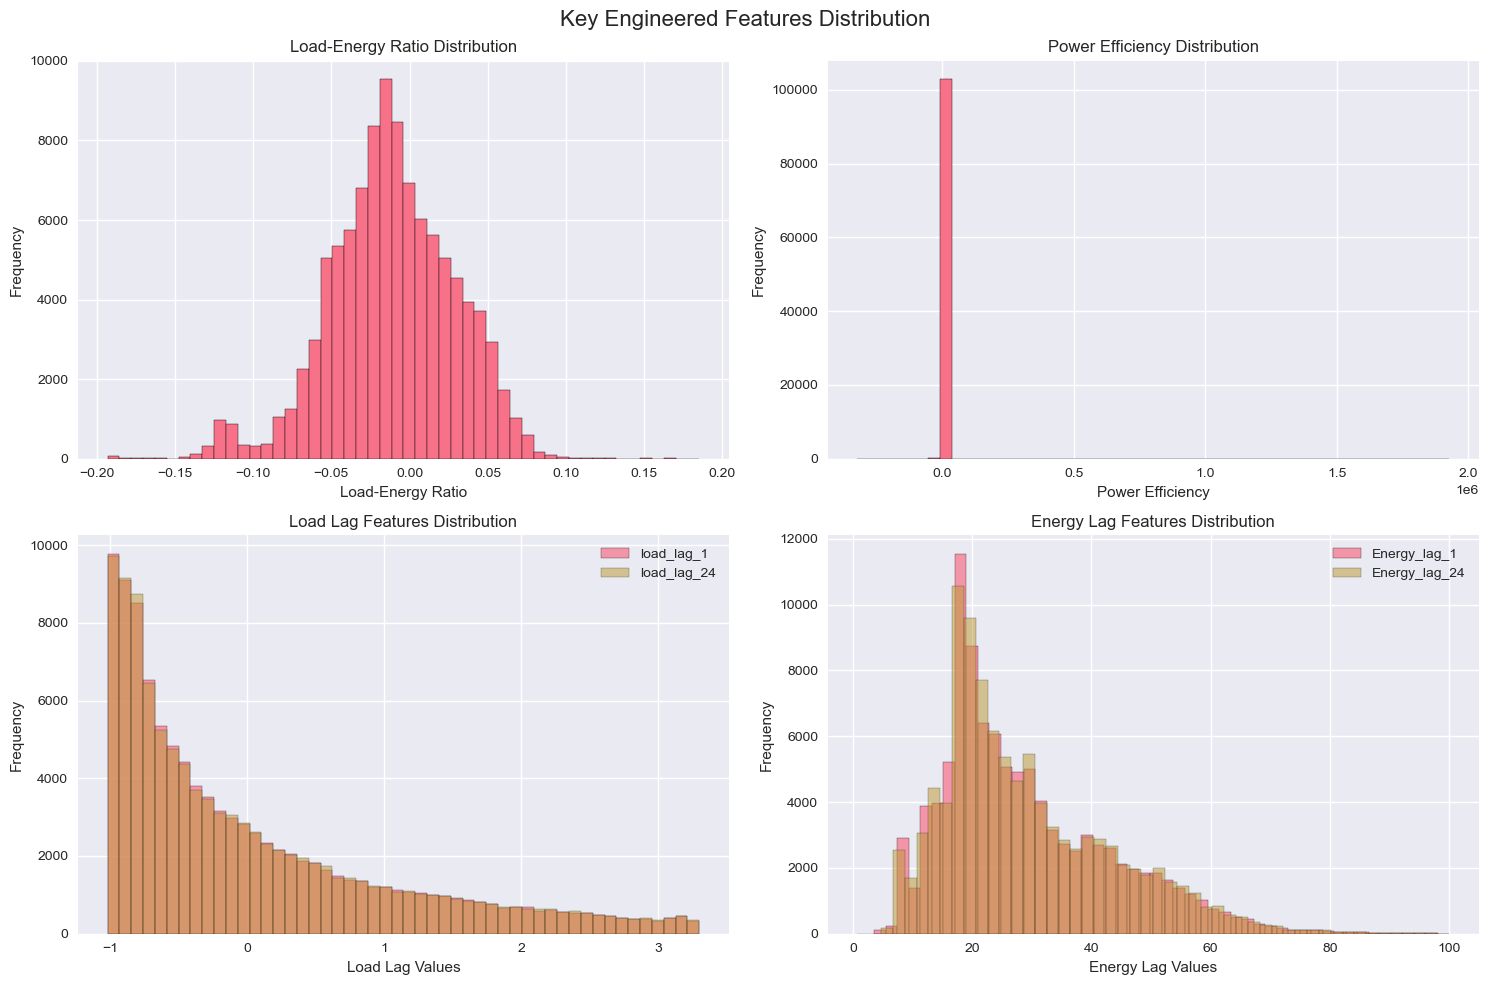

In [37]:
# Visualization of final features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Key Engineered Features Distribution', fontsize=16)

# Load-energy ratio
axes[0, 0].hist(merged_data_final['load_energy_ratio'], bins=50, edgecolor='black')
axes[0, 0].set_title('Load-Energy Ratio Distribution')
axes[0, 0].set_xlabel('Load-Energy Ratio')
axes[0, 0].set_ylabel('Frequency')

# Power efficiency
axes[0, 1].hist(merged_data_final['power_efficiency'], bins=50, edgecolor='black')
axes[0, 1].set_title('Power Efficiency Distribution')
axes[0, 1].set_xlabel('Power Efficiency')
axes[0, 1].set_ylabel('Frequency')

# Load lag features
axes[1, 0].hist(merged_data_final['load_lag_1'], bins=50, edgecolor='black', alpha=0.7, label='load_lag_1')
axes[1, 0].hist(merged_data_final['load_lag_24'], bins=50, edgecolor='black', alpha=0.5, label='load_lag_24')
axes[1, 0].set_title('Load Lag Features Distribution')
axes[1, 0].set_xlabel('Load Lag Values')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# Energy lag features
axes[1, 1].hist(merged_data_final['Energy_lag_1'], bins=50, edgecolor='black', alpha=0.7, label='Energy_lag_1')
axes[1, 1].hist(merged_data_final['Energy_lag_24'], bins=50, edgecolor='black', alpha=0.5, label='Energy_lag_24')
axes[1, 1].set_title('Energy Lag Features Distribution')
axes[1, 1].set_xlabel('Energy Lag Values')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

plt.tight_layout()
plt.show()
